# **Ejercicio 8: Prueba con señas propias**

Probar el mejor modelo con fotografias de señas hechas a mano por los integrantes del grupo,
minimo 5 letras distintas por integrante, y discutir el desempeño y los resultados obtenidos.

Las fotografias van en `data/own_signs/<nombre>/`, una carpeta por integrante. Esa carpeta si
se versiona, a diferencia del dataset de Kaggle, porque no se puede volver a descargar.

Las imagenes deben pasar por el mismo preprocesamiento que el resto: escala de grises, 64x64 y
normalizacion a [0, 1]. De lo contrario el modelo recibe una entrada distinta a la que aprendio.

El "mejor modelo" se selecciona comparando las tres variantes campeonas de cada familia
(`05_augmentation`) sobre `x_test`, la particion que ninguna de ellas uso durante el
entrenamiento ni la seleccion de hiperparametros. Solo esa variante se prueba despues contra
las fotos propias.

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import config as cfg
import modelado as m

MODO_GRISES = "L"
FILTRO = Image.Resampling.LANCZOS

## **Preprocesamiento de las fotos propias**

Se reutiliza la misma logica de `src/02_preprocesamiento.py` (grises, 64x64 con LANCZOS,
normalizacion a [0, 1]), con un ajuste: las fotos del dataset de Kaggle ya vienen derechas,
pero las tomadas con celular traen un tag EXIF de orientacion (el telefono se sostuvo en
vertical) que Pillow no aplica solo. Sin corregirlo la imagen se ve girada 90 grados, una
entrada que el modelo nunca vio en el entrenamiento y que no tiene nada que ver con la seña en
si. Por eso se aplica `ImageOps.exif_transpose` antes de todo lo demas.

In [4]:
def procesar_imagen_propia(ruta):
    """Misma transformacion que 02_preprocesamiento, mas correccion de orientacion EXIF."""
    with Image.open(ruta) as img:
        img = ImageOps.exif_transpose(img)
        img = img.convert(MODO_GRISES).resize((cfg.RESOLUCION, cfg.RESOLUCION), FILTRO)
        return np.asarray(img, dtype=np.float32) / 255.0


registros = []
for carpeta in sorted(cfg.RUTA_SENAS_PROPIAS.iterdir()):
    if not carpeta.is_dir():
        continue
    for ruta in sorted(carpeta.iterdir()):
        letra = ruta.stem
        if ruta.name.startswith(".") or letra not in cfg.CLASES:
            continue
        registros.append({"integrante": carpeta.name, "letra": letra, "ruta": ruta})

meta = pd.DataFrame(registros)
indice_clase = {clase: i for i, clase in enumerate(cfg.CLASES)}

x_propio = np.zeros((len(meta), cfg.RESOLUCION, cfg.RESOLUCION, cfg.CANALES), dtype=np.float32)
y_propio = np.zeros(len(meta), dtype=np.int16)
for i, fila in meta.iterrows():
    x_propio[i, :, :, 0] = procesar_imagen_propia(fila["ruta"])
    y_propio[i] = indice_clase[fila["letra"]]

print(f"[cargado] {len(meta)} fotos propias de {meta['integrante'].nunique()} integrantes, "
      f"letras: {sorted(meta['letra'].unique())}")
meta.groupby("integrante")["letra"].apply(lambda s: ", ".join(sorted(s)))

[cargado] 15 fotos propias de 3 integrantes, letras: ['A', 'B', 'C', 'D', 'E']


integrante
Adriana    A, B, C, D, E
Benitez    A, B, C, D, E
Bryan      A, B, C, D, E
Name: letra, dtype: object

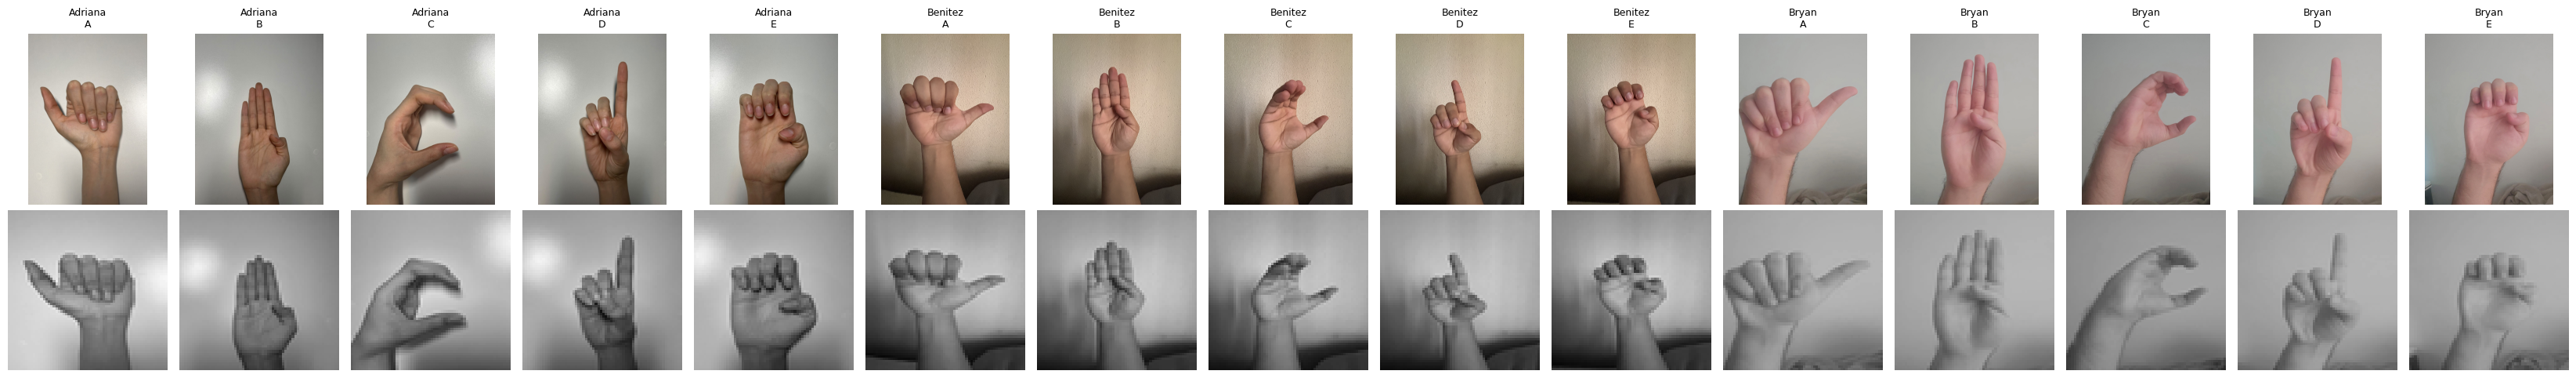

In [5]:
fig, ejes = plt.subplots(2, len(meta), figsize=(2.2 * len(meta), 5))
for col, (_, fila) in enumerate(meta.iterrows()):
    with Image.open(fila["ruta"]) as original:
        original = ImageOps.exif_transpose(original)
        ejes[0, col].imshow(original)
    ejes[0, col].set_title(f"{fila['integrante']}\n{fila['letra']}", fontsize=9)
    ejes[1, col].imshow(x_propio[col].squeeze(), cmap="gray", vmin=0, vmax=1)
    for fil in (0, 1):
        ejes[fil, col].axis("off")

ejes[0, 0].set_ylabel("original", fontsize=9)
ejes[1, 0].set_ylabel("preprocesada", fontsize=9)
plt.tight_layout()
plt.show()

## **Seleccion del mejor modelo**

Se cargan las tres variantes campeonas de `05_augmentation` (una por familia) y se evaluan
sobre `x_test`, que es la particion reservada para la comparacion final entre familias. La
validacion aumentada, al ser la que se uso para el `EarlyStopping`, ya no es un juez imparcial;
`x_test` nunca fue tocada por ninguna de las tres.

In [6]:
import json

import joblib
import tensorflow as tf

candidatos = {
    "cnn_base_aug": tf.keras.models.load_model(cfg.DIR_MODELOS / "cnn_base_aug.keras"),
    "random_forest_aug": joblib.load(cfg.DIR_MODELOS / "random_forest_aug.joblib"),
    "red_simple_aug": tf.keras.models.load_model(cfg.DIR_MODELOS / "red_simple_aug.keras"),
}

datos = m.cargar_tensores()
comparacion = pd.DataFrame([
    {"modelo": nombre,
     "accuracy_val": json.loads((cfg.DIR_RESULTADOS / f"{nombre}.json").read_text())["accuracy"],
     "accuracy_test": m.evaluar(modelo, datos, "test")["accuracy"]}
    for nombre, modelo in candidatos.items()
]).sort_values("accuracy_test", ascending=False)

nombre_mejor = comparacion.iloc[0]["modelo"]
modelo = candidatos[nombre_mejor]
print(f"\n[seleccionado] {nombre_mejor}")
comparacion

/Users/bryan/VirtualEnv/venv/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/bryan/VirtualEnv/venv/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


[ok] entrada (64, 64, 1)
[cargado]  tensores -> train 12180, val 2610, test 2610
[info] accuracy en test: 0.9529
[info] accuracy en test: 0.9709
[info] accuracy en test: 0.6195

[seleccionado] random_forest_aug


,modelo,accuracy_val,accuracy_test
1,random_forest_aug,0.968582,0.970881
0,cnn_base_aug,0.963985,0.952874
2,red_simple_aug,0.608046,0.619540


In [7]:
predicciones = m.predecir(modelo, x_propio)
resultados = meta.copy()
resultados["prediccion"] = [cfg.CLASES[p] for p in predicciones]
resultados["correcto"] = resultados["prediccion"] == resultados["letra"]

resultados

,integrante,letra,ruta,prediccion,correcto
0,Adriana,A,/Users/bryan/Documents/DataScience/Laboratorio...,J,False
1,Adriana,B,/Users/bryan/Documents/DataScience/Laboratorio...,L,False
2,Adriana,C,/Users/bryan/Documents/DataScience/Laboratorio...,nothing,False
3,Adriana,D,/Users/bryan/Documents/DataScience/Laboratorio...,W,False
4,Adriana,E,/Users/bryan/Documents/DataScience/Laboratorio...,Y,False
5,Benitez,A,/Users/bryan/Documents/DataScience/Laboratorio...,nothing,False
6,Benitez,B,/Users/bryan/Documents/DataScience/Laboratorio...,nothing,False
7,Benitez,C,/Users/bryan/Documents/DataScience/Laboratorio...,nothing,False
8,Benitez,D,/Users/bryan/Documents/DataScience/Laboratorio...,nothing,False
9,Benitez,E,/Users/bryan/Documents/DataScience/Laboratorio...,nothing,False


In [8]:
print(f"modelo: {nombre_mejor}")
print(f"accuracy en test (Kaggle)  : {comparacion.iloc[0]['accuracy_test']:.4f}")
print(f"accuracy en senas propias  : {resultados['correcto'].mean():.4f} "
      f"({resultados['correcto'].sum()}/{len(resultados)})")

modelo: random_forest_aug
accuracy en test (Kaggle)  : 0.9709
accuracy en senas propias  : 0.0000 (0/15)


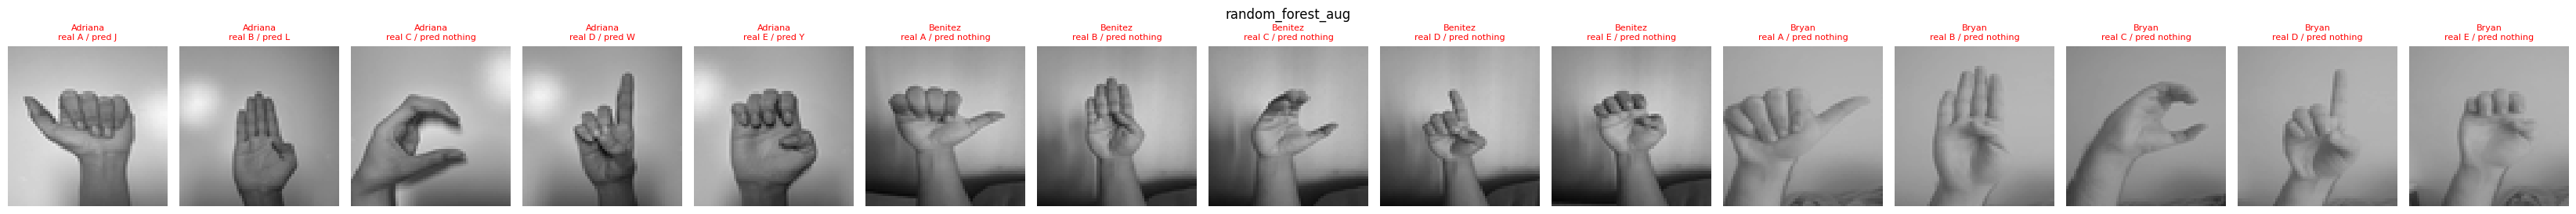

In [9]:
fig, ejes = plt.subplots(1, len(meta), figsize=(2.2 * len(meta), 2.8))
for col, (_, fila) in enumerate(resultados.iterrows()):
    ejes[col].imshow(x_propio[col].squeeze(), cmap="gray", vmin=0, vmax=1)
    color = "green" if fila["correcto"] else "red"
    ejes[col].set_title(f"{fila['integrante']}\nreal {fila['letra']} / pred {fila['prediccion']}",
                         fontsize=8, color=color)
    ejes[col].axis("off")

fig.suptitle(nombre_mejor)
plt.tight_layout()
plt.show()

In [10]:
fallos = resultados[~resultados["correcto"]]
print(f"Errores de {nombre_mejor}:")
if fallos.empty:
    print("  ninguno")
else:
    for _, fila in fallos.iterrows():
        print(f"  {fila['integrante']:8s} {fila['letra']} predicha como {fila['prediccion']}")

Errores de random_forest_aug:
  Adriana  A predicha como J
  Adriana  B predicha como L
  Adriana  C predicha como nothing
  Adriana  D predicha como W
  Adriana  E predicha como Y
  Benitez  A predicha como nothing
  Benitez  B predicha como nothing
  Benitez  C predicha como nothing
  Benitez  D predicha como nothing
  Benitez  E predicha como nothing
  Bryan    A predicha como nothing
  Bryan    B predicha como nothing
  Bryan    C predicha como nothing
  Bryan    D predicha como nothing
  Bryan    E predicha como nothing


## **Las tres familias contra las fotos propias**

Se evaluan tambien las otras dos variantes campeonas sobre las mismas 15 fotografias. El
proposito no es cambiar la seleccion, que ya se hizo sobre `x_test`, sino comprobar si el
colapso es exclusivo del modelo elegido o si afecta por igual a las tres familias.

In [11]:
filas = []
for nombre, mod in candidatos.items():
    p = m.predecir(mod, x_propio)
    filas.append({
        "modelo": nombre,
        "accuracy_test": comparacion.loc[comparacion["modelo"] == nombre, "accuracy_test"].iloc[0],
        "aciertos_propias": int((p == y_propio).sum()),
        "accuracy_propias": round(float((p == y_propio).mean()), 4),
        "predijo_nothing": int(sum(1 for i in p if cfg.CLASES[i] == "nothing")),
    })

pd.DataFrame(filas).sort_values("accuracy_test", ascending=False)

,modelo,accuracy_test,aciertos_propias,accuracy_propias,predijo_nothing
1,random_forest_aug,0.970881,0,0.0000,11
0,cnn_base_aug,0.952874,1,0.0667,0
2,red_simple_aug,0.619540,0,0.0000,3


### **Discusion**

El modelo seleccionado es `random_forest_aug`: de las tres variantes campeonas es la que mejor
generaliza sobre `x_test`, con 0.9709 de accuracy (0.9686 en validacion, 0.9529 la CNN y 0.6195
la red simple sobre ese mismo test). Es, sin ambiguedad, el mejor modelo de los tres construidos
en este laboratorio para clasificar las 29 clases del dataset de Kaggle.

Frente a las 15 fotos propias (5 letras x 3 integrantes) ese mismo modelo no acierta ninguna:
0/15, accuracy 0.0000. En 10 de los 15 casos, todas las fotos de Benitez y de Bryan, la
prediccion fue directamente `nothing`, es decir que el modelo ni siquiera reconocio que habia
una mano en la imagen. Con las fotos de Adriana si intento clasificar una letra (J, L, W, Y),
pero ninguna correcta.

El contraste es total: el mismo modelo que acierta 97 de cada 100 imagenes del dataset de
Kaggle acierta 0 de 15 fotos tomadas con celular. Esto no se explica por una seña mal hecha,
las cinco letras (A-E) son de las mas simples del alfabeto y las tres personas las hicieron de
forma reconocible a simple vista; se explica por un cambio de distribucion. Como ya señalaba el
EDA (`01_eda`), dentro de cada clase del dataset el fondo y la iluminacion son consistentes,
señal de pocas sesiones de grabacion repetidas miles de veces en vez de miles de personas
distintas en condiciones distintas. Las fotos propias rompen justamente eso: fondo de un cuarto
real en vez de fondo de estudio, distancia y encuadre libres en vez de fijos, camara de celular
en vez de la camara del dataset.

La razon por la que el Random Forest en particular colapsa hacia `nothing` tiene que ver con
como construye sus arboles: entrena sobre pixeles aplanados (`aplanar` en `src/modelado.py`, de
64x64x1 a 4096 caracteristicas), y cada corte de cada arbol se hace sobre el valor de un pixel
en una **posicion fija** del encuadre. Eso funciona mientras la posicion (x, y) siempre caiga
sobre la mano o siempre sobre el fondo, como ocurre en el dataset de Kaggle, pero deja de
funcionar en cuanto la mano se desplaza, cambia de tamaño o el fondo deja de ser uniforme. A
diferencia de una CNN, que gracias a las convoluciones y al pooling puede reconocer un patron
sin importar en que parte exacta de la imagen aparece, el Random Forest no tiene ningun
mecanismo de invarianza a traslacion o escala. Bajo un fondo desconocido, la combinacion de
pixeles que ve cada arbol termina pareciendose mas a la clase "sin mano visible" que a
cualquier letra, que es exactamente lo que se observo en 10 de los 15 casos.

Este resultado deja evidencia concreta y no especulativa de que un accuracy alto en un dataset
controlado no garantiza nada sobre el desempeño en un escenario de uso real, y es el punto de
partida de la discusion de accesibilidad y sesgo del siguiente notebook (`07`).